# Notebook 02 — Funnel Analysis
**Project:** E-Commerce Revenue Leakage  
**Input:** `../data/processed/events_clean.parquet`  
**Output:** `charts/chart_02.png`, `chart_03.png`, `chart_04.png`

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import os

os.makedirs('charts', exist_ok=True)

TEAL   = '#1D9E75'
AMBER  = '#EF9F27'
CORAL  = '#D85A30'
BLUE   = '#4A90D9'
GRAY   = '#888888'

df = pd.read_parquet('../data/processed/events_clean.parquet')
print(f"Loaded: {len(df):,} rows")
df['event_time'] = pd.to_datetime(df['event_time'], utc=True)
df['event_month'] = pd.to_datetime(df['event_month'])

Loaded: 884,474 rows


## 2.1 Session-Level Funnel

In [2]:
session_funnel = df.groupby(['user_id', 'user_session'])['event_type'].apply(
    lambda x: set(x)
).reset_index()

total_sessions   = len(session_funnel)
sessions_view    = session_funnel['event_type'].apply(lambda s: 'view' in s).sum()
sessions_cart    = session_funnel['event_type'].apply(lambda s: 'cart' in s).sum()
sessions_purchase = session_funnel['event_type'].apply(lambda s: 'purchase' in s).sum()

view_to_cart_pct     = 100 * sessions_cart     / sessions_view
cart_to_purchase_pct = 100 * sessions_purchase / sessions_cart
overall_pct          = 100 * sessions_purchase / sessions_view

print(f"Total sessions:          {total_sessions:>10,}")
print(f"Sessions with view:      {sessions_view:>10,}")
print(f"Sessions with cart add:  {sessions_cart:>10,}")
print(f"Sessions with purchase:  {sessions_purchase:>10,}")
print()
print(f"View → Cart:             {view_to_cart_pct:>9.2f}%")
print(f"Cart → Purchase:         {cart_to_purchase_pct:>9.2f}%")
print(f"Overall (View → Buy):    {overall_pct:>9.2f}%")

Total sessions:             490,633
Sessions with view:         488,586
Sessions with cart add:      41,278
Sessions with purchase:      24,348

View → Cart:                  8.45%
Cart → Purchase:             58.99%
Overall (View → Buy):         4.98%


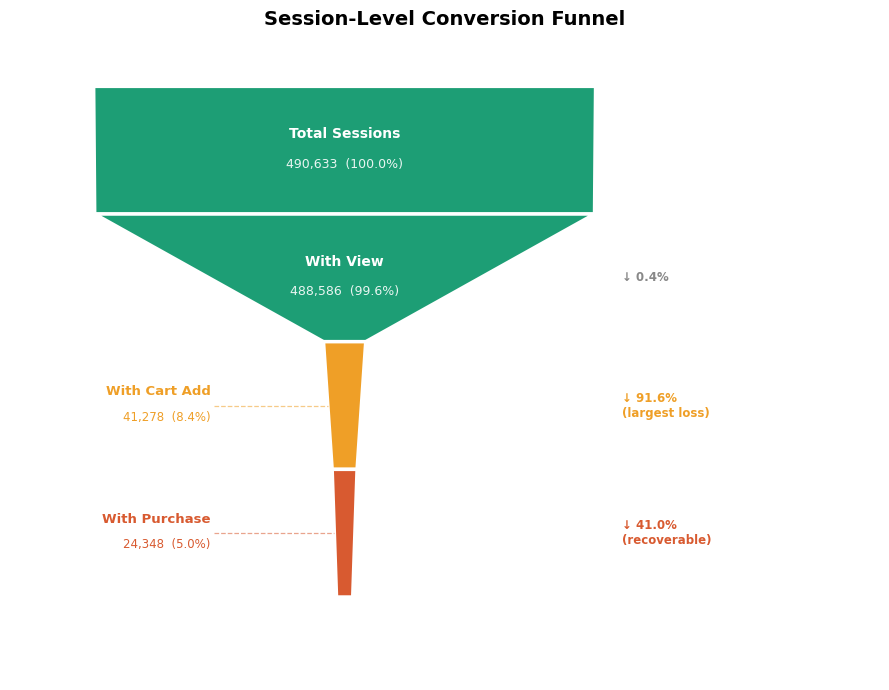

Saved: charts/Conversion_Funnel.png


In [3]:
# Chart 02 — Session-level funnel (true funnel shape, trapezoid per stage)
from matplotlib.patches import Polygon as MplPolygon

stages  = ['Total Sessions', 'With View', 'With Cart Add', 'With Purchase']
counts  = [total_sessions, sessions_view, sessions_cart, sessions_purchase]
colors  = [TEAL, TEAL, AMBER, CORAL]
n       = len(stages)
seg_h   = 0.20
y_start = 0.93
max_w   = 0.75

# Same business metrics as before
view_to_cart_drop = 100 * (1 - sessions_cart  / sessions_view)
cart_abandon_pct  = 100 - cart_to_purchase_pct

widths = [max_w * c / counts[0] for c in counts]

fig, ax = plt.subplots(figsize=(9, 7))
ax.set_xlim(0, 1.3)
ax.set_ylim(0, 1)
ax.axis('off')

for i in range(n):
    y_top = y_start - i * seg_h
    y_bot = y_top - seg_h
    w_top = widths[i]
    w_bot = widths[i + 1] if i + 1 < n else widths[i] * 0.65  # taper last stage to a tip

    ax.add_patch(MplPolygon(
        [(0.5 - w_top/2, y_top), (0.5 + w_top/2, y_top),
         (0.5 + w_bot/2, y_bot), (0.5 - w_bot/2, y_bot)],
        closed=True, facecolor=colors[i], edgecolor='white', linewidth=2.5
    ))

    y_mid = (y_top + y_bot) / 2
    pct   = 100 * counts[i] / counts[0]

    if i < 2:
        # Total Sessions and With View: wide enough for white labels inside
        ax.text(0.5, y_mid + 0.025, stages[i],
                ha='center', va='center', fontsize=10, fontweight='bold', color='white')
        ax.text(0.5, y_mid - 0.022, f'{counts[i]:,}  ({pct:.1f}%)',
                ha='center', va='center', fontsize=9, color='white', alpha=0.9)
    else:
        # With Cart Add and With Purchase: too narrow — labels outside left with leader line
        label_col   = colors[i]
        label_x     = 0.30
        left_edge_x = 0.5 - (w_top + w_bot) / 4  # midpoint of left slanted edge
        ax.plot([label_x + 0.005, left_edge_x], [y_mid, y_mid],
                color=label_col, lw=0.9, alpha=0.55, linestyle='--')
        ax.text(label_x, y_mid + 0.022, stages[i],
                ha='right', va='center', fontsize=9.5, fontweight='bold', color=label_col)
        ax.text(label_x, y_mid - 0.018, f'{counts[i]:,}  ({pct:.1f}%)',
                ha='right', va='center', fontsize=8.5, color=label_col)

# Primary annotation: largest ABSOLUTE loss is View → Cart
# Secondary annotation: cart abandonment is the recoverable business opportunity
right_x = 0.5 + max_w / 2
for i in range(1, n):
    y_mid     = y_start - i * seg_h - seg_h / 2
    drop_pct  = 100 * (1 - counts[i] / counts[i - 1])
    color_ann = AMBER if i == 2 else (CORAL if i == 3 else GRAY)
    suffix    = '\n(largest loss)' if i == 2 else ('\n(recoverable)' if i == 3 else '')
    ax.text(right_x + 0.04, y_mid,
            f'↓ {drop_pct:.1f}%{suffix}',
            ha='left', va='center', fontsize=8.5, color=color_ann, fontweight='bold')

ax.set_title('Session-Level Conversion Funnel', fontsize=14, fontweight='bold', pad=12)

plt.tight_layout()
plt.savefig('charts/Conversion_Funnel.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: charts/Conversion_Funnel.png")

<!-- Section 2.2 (user-level funnel / Chart 03) removed — 0.4 pp delta vs session-level does not earn a full chart -->

## 2.3 Funnel Over Time (Monthly Trend)

In [4]:
# Compute session-level funnel per month
df['event_month'] = pd.to_datetime(df['event_month'])

monthly_records = []
for month, grp in df.groupby('event_month'):
    sess = grp.groupby(['user_id', 'user_session'])['event_type'].apply(set)
    n_view     = sess.apply(lambda s: 'view' in s).sum()
    n_cart     = sess.apply(lambda s: 'cart' in s).sum()
    n_purchase = sess.apply(lambda s: 'purchase' in s).sum()
    monthly_records.append({
        'month': month,
        'view_to_cart_pct':     round(100 * n_cart / n_view, 2)     if n_view     else 0,
        'cart_to_purchase_pct': round(100 * n_purchase / n_cart, 2) if n_cart     else 0,
        'overall_pct':          round(100 * n_purchase / n_view, 2) if n_view     else 0,
    })

monthly = pd.DataFrame(monthly_records).sort_values('month')
print(monthly.to_string(index=False))

     month  view_to_cart_pct  cart_to_purchase_pct  overall_pct
2020-09-01              6.61                 59.61         3.94
2020-10-01              7.17                 60.48         4.34
2020-11-01              7.52                 60.19         4.53
2020-12-01              8.54                 59.51         5.08
2021-01-01              9.74                 57.22         5.57
2021-02-01              9.66                 57.80         5.58


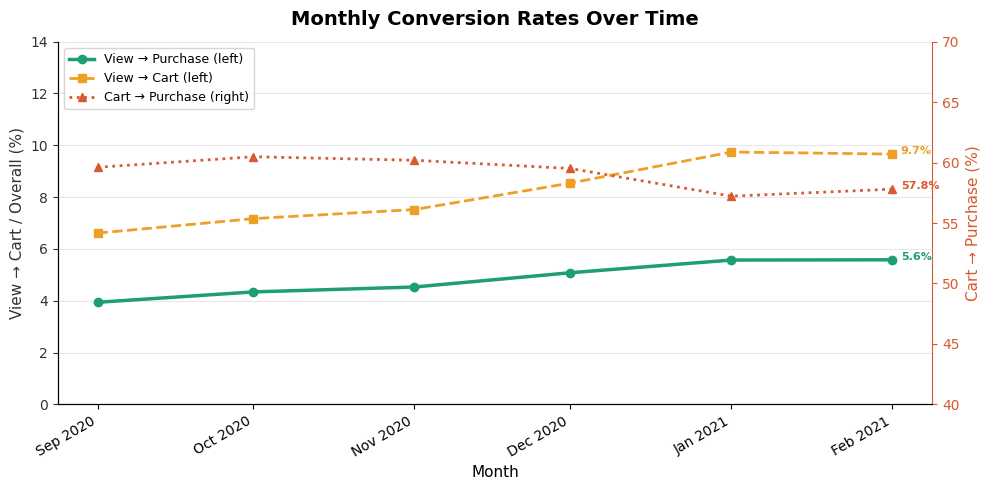

Saved: charts/Monthly_Conversion_Trend.png


In [5]:
# Chart 04 — Monthly conversion trend (dual Y-axis to avoid compression)
fig, ax = plt.subplots(figsize=(10, 5))
ax2 = ax.twinx()

# Left axis: Overall (View→Purchase) and View→Cart — both in the 0–12 % range
ax.plot(monthly['month'], monthly['overall_pct'],
        color=TEAL, marker='o', linewidth=2.5, label='View → Purchase (left)')
ax.plot(monthly['month'], monthly['view_to_cart_pct'],
        color=AMBER, marker='s', linewidth=2, linestyle='--', label='View → Cart (left)')
ax.set_ylabel('View → Cart / Overall (%)', fontsize=11, color='#333')
ax.set_ylim(0, 14)
ax.tick_params(axis='y', colors='#333')

# Right axis: Cart→Purchase — lives in the 55–65 % range
ax2.plot(monthly['month'], monthly['cart_to_purchase_pct'],
         color=CORAL, marker='^', linewidth=2, linestyle=':', label='Cart → Purchase (right)')
ax2.set_ylabel('Cart → Purchase (%)', fontsize=11, color=CORAL)
ax2.tick_params(axis='y', colors=CORAL)
ax2.set_ylim(40, 70)
ax2.spines['right'].set_edgecolor(CORAL)

# Annotate last data-point for each left-axis series
last = monthly.iloc[-1]
ax.annotate(f"{last['overall_pct']:.1f}%",
            (last['month'], last['overall_pct']),
            textcoords='offset points', xytext=(6, 0),
            ha='left', fontsize=8, color=TEAL, fontweight='bold')
ax.annotate(f"{last['view_to_cart_pct']:.1f}%",
            (last['month'], last['view_to_cart_pct']),
            textcoords='offset points', xytext=(6, 0),
            ha='left', fontsize=8, color=AMBER, fontweight='bold')
ax2.annotate(f"{last['cart_to_purchase_pct']:.1f}%",
             (last['month'], last['cart_to_purchase_pct']),
             textcoords='offset points', xytext=(6, 0),
             ha='left', fontsize=8, color=CORAL, fontweight='bold')

ax.set_title('Monthly Conversion Rates Over Time', fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Month', fontsize=11)
lines1, labels1 = ax.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax.legend(lines1 + lines2, labels1 + labels2, fontsize=9, loc='upper left')
ax.spines[['top', 'right']].set_visible(False)
ax2.spines[['top']].set_visible(False)
ax.grid(axis='y', alpha=0.3)
ax.xaxis.set_major_formatter(plt.matplotlib.dates.DateFormatter('%b %Y'))
fig.autofmt_xdate(rotation=30)

plt.tight_layout()
plt.savefig('charts/Monthly_Conversion_Trend.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: charts/Monthly_Conversion_Trend.png")

## Key Finding

> **The cart-to-purchase step is the largest drop-off in the funnel.**  
> A user who adds to cart is expressing strong purchase intent — yet the majority leave before completing checkout.  
> This is the highest-leverage intervention point: improving cart conversion has a compounding effect on overall revenue without requiring more top-of-funnel traffic.